In [1]:
from utils import *
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from scipy.ndimage import gaussian_filter
from ripser import ripser
from tqdm import tqdm
from persim import wasserstein, bottleneck

In [3]:

# stimulus 1 template
# by loop we mean neurons will fire in a sequence looping back: 1->2->3...->12->1
# from turtle import pd
import pandas as pd


def make_loop_template(n_neurons=12, T=500, arc_width=80):
    raster = np.zeros((n_neurons, T), dtype=int) #initial raster with zeros
    centers = np.linspace(0, T, n_neurons, endpoint=False).astype(int) # for each neuron pick a center equally spread.
    half = arc_width // 2 # we'll ensure that spikes overlap
    for i, c in enumerate(centers): # neuron i, center c
        idx = (np.arange(c - half, c + half) % T).astype(int) # spike times of neuron i. Modulo T ensures a spike at time say 495ms wraps around to 5ms.
        raster[i, idx] = 1 
    return raster

# stimulus 2 template.
# this willl be similar as above.
# but by path we mean neurons will form a chain but do not loop back: 1->2->3...->12. 
def make_path_template(n_neurons=12, T=500, arc_width=80):
    raster = np.zeros((n_neurons, T), dtype=int)
    half = arc_width // 2
    centers = np.linspace(half, T - half, n_neurons).astype(int)
    for i, c in enumerate(centers):
        idx = np.arange(c - half, c + half)
        idx = idx[(idx >= 0) & (idx < T)] # we remove the modulo operator here. If a spike goes past 500ms, it is timply cut off.
        raster[i, idx] = 1
    return raster


# Optinmization process. Simulated Annealing (SA)
def optimize_stim2_template(stim1_template, n_steps=1000, initial_temp=1.5):
    """Optimizes Stim2 using Wasserstein distance to match Stim1's H0."""
    def get_dgms(raster): #helper function to compute PH of a given raster.
        return ripser(VP_trivial(raster), distance_matrix=True, maxdim=1)['dgms']
        
    target_h0 = get_dgms(stim1_template)[0] # H0 barcode of stim1_template. 
    n_neurons, T = stim1_template.shape
    current_raster = make_path_template(n_neurons, T) # stim2 template of same shape as stim1. 
    # We want to optimize this so that "current_raster" has similar H0 structure, and little to no H1.
    
    # we set up an optimization task with the following loss function:
    # Loss (input barcode) = W(H0 barcode of stim1 template,H0 of input) + 10 * (Total persistence in H1 features of input)
    # this loss is minimize when H0 of input closely matches with H0 of stim1 template, and when H1 of input does not exist or small in persistence.
    def calc_loss(dgms):
        h0, h1 = dgms
        
        # Filter out points with infinite death times
        h0_finite = h0[np.isfinite(h0[:, 1])]
        target_h0_finite = target_h0[np.isfinite(target_h0[:, 1])]
        
        # Calculate Wasserstein distance
        loss_h0 = wasserstein(h0_finite, target_h0_finite, matching=False) 
        loss_h1 = np.sum(h1[:, 1] - h1[:, 0]) if len(h1) > 0 else 0.0 # total persistence of H1 features.

        return loss_h0 + 10.0 * loss_h1 # Keep H1 penalized

    # setting up Simulated Annealing (SA) optimization. A gradient-free optimization technique.
    current_loss = calc_loss(get_dgms(current_raster)) # calculate loss of current_raster
    best_raster = current_raster.copy() # keep track of best raster during the search
    best_loss = current_loss # keep track of best loss during the search
    temp = initial_temp # temperature (terminology in the context of SA)
    
    for _ in tqdm(range(n_steps), desc="Optimizing Stim2"):
        neuron_idx = np.random.randint(n_neurons) # pick one random neuron.
        spikes = np.where(current_raster[neuron_idx] == 1)[0] # get its spike times
        if len(spikes) == 0: continue
            
        spike_to_move = np.random.choice(spikes) # pick one of its spike randomly.
        shift = np.random.randint(-10, 11) # move that spike a few milliseconds left or right.
        new_pos = (spike_to_move + shift) % T # new position of that spike.
        if current_raster[neuron_idx, new_pos] == 1: continue # if the spot is already taken, abort. Try again.
        
        # form new raster with the shifted spike.
        proposed_raster = current_raster.copy() 
        proposed_raster[neuron_idx, spike_to_move] = 0 # delete that spike.
        proposed_raster[neuron_idx, new_pos] = 1 # move it to its new position.
        
        proposed_loss = calc_loss(get_dgms(proposed_raster)) # calculate the loss of the proposed_raster.
        
        # We will accept the proposed raster depending on few conditions:
        # if the updated raster's loss is less than before, accept it immediately.
        # Otherwise we check the second condition: "np.random.rand() < np.exp(-(proposed_loss - current_loss) / temp)" 
        # which prevents the optimizer from getting stuck in a local min.
        # we may still accept this depending on temp: if it is high, the probability of accepting a bad move is high. Otherwise, it is low.
        # and depending on whether on the proposed loss. If it is really high, then the prob of accepting a bad move is also low.
        if proposed_loss < current_loss or np.random.rand() < np.exp(-(proposed_loss - current_loss) / temp):
            current_raster = proposed_raster
            current_loss = proposed_loss
            if current_loss < best_loss: # checking if the accepted raster's loss is better than the all time best. If it is, we record this as the best so far.
                best_loss = current_loss
                best_raster = current_raster.copy()
        temp *= 0.995 # temperature is high early on (meaning it explores wild) but as we slowly refine it to a tighter range of exploration.
        
    print(f"Final Optimized Stim2 Loss: {best_loss:.4f}")
    return best_raster # return the best_raster after search is finished.


# Define a function to introduce noise to the raster with a specified noise level---that is either randomly shift some spikes by a small random amount and/or randomly add or remove spikes in the raster.
def add_noise_to_raster(raster, noise_level_shift=1.0 ,shift_strength = 50, noise_level_add =0.1, noise_level_remove = 0.05,  random_state=None):
    """
    Add noise to the raster data by randomly shifting spikes and adding/removing spikes.
    Parameters:
    raster (np.ndarray): The original raster data (2D array: neurons x time).
    noise_level_shift (float): Probability of shifting each spike.
    shift_strength (int): Maximum amount to shift a spike.
    noise_level_add (float): Probability of adding a spike at an empty bin.
    noise_level_remove (float): Probability of removing an existing spike.
    random_state: int, np.random.Generator, or None for reproducibility.
    
    Default values: noise_level_shift=0.05 ,shift_strength = 2, noise_level_add =0.1, noise_level_remove = 0.05
    Returns:
    np.ndarray: The noisy raster data (same shape as input).
    """
    rng = np.random.default_rng(random_state)
    noisy_raster = raster.copy()

    # 1. Randomly remove spikes. Only applicable if there is a spike at that time point.
    for i in range(noisy_raster.shape[0]):
        for j in range(noisy_raster.shape[1]):
            if noisy_raster[i, j] > 0 and rng.random() < noise_level_remove:
                noisy_raster[i, j] = 0
    
    # 2. Randomly shift some spikes in time
    for i in range(noisy_raster.shape[0]):
        for j in range(noisy_raster.shape[1]):
            if noisy_raster[i, j] > 0 and rng.random() < noise_level_shift:
                shift = rng.integers(-shift_strength, shift_strength + 1)  # Shift by -shift_strength to +shift_strength ms
                new_j = j + shift
                # only shift if there is no spike at the new time point
                if 0 <= new_j < noisy_raster.shape[1] and noisy_raster[i, new_j] == 0:
                    noisy_raster[i, j] = 0  # Remove original spike
                    noisy_raster[i, new_j] = 1  # Add shifted spike
             
    # 3. Randomly add spikes. Only applicable if there is no spike at that time point.
    for i in range(noisy_raster.shape[0]):
        for j in range(noisy_raster.shape[1]):
            if noisy_raster[i, j] == 0 and rng.random() < noise_level_add:
                noisy_raster[i, j] = 1

    return noisy_raster


def generate_trials(template, n_trials=30, random_state=42, permute=False):
    """Generates noisy trials from a given template raster."""
    rng = np.random.default_rng(random_state)
    n_neurons, T = template.shape
    trials = []
    for _ in range(n_trials):
        noisy = add_noise_to_raster(template, random_state=rng) # this is noisy raster generated from the template.
        
        shifted = np.roll(noisy, rng.integers(0, T), axis=1) # we will process this again by shifting all spikes by a random integer specified by rng.integers(0, T)
        # this will ensure same topological pattern but at distinct times.

        if permute:
            trials.append(shifted[rng.permutation(n_neurons), :]) # optionally we can permute the neuron labels too. Topology will remain the same.
        else:
            trials.append(shifted)
            
    return np.array(trials)


def rasters_to_barcode(list_of_rasters, dim=0):
    list_of_barcodes = []
    # Force maxdim to at least 1 if dim=1 is requested
    calc_dim = max(dim, 1) 
    for raster in tqdm(list_of_rasters, desc=f"Generating barcodes (dim={dim})"):
        vp_dm = VP_trivial(raster)
        dgm = ripser(vp_dm, distance_matrix=True, maxdim=calc_dim)['dgms'][dim]
        list_of_barcodes.append(dgm)
    return list_of_barcodes

def svm_smoothed_rasters(rasters, labels, sigma=30, n_repeats=20, test_size=0.3):
    X = np.array([gaussian_filter(r.astype(float), sigma=(0, sigma)).flatten() for r in rasters])
    y = np.array(labels)
    splitter = StratifiedShuffleSplit(n_splits=n_repeats, test_size=test_size, random_state=42)
    svm = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0))
    
    scores, y_true_all, y_pred_all = [], [], []
    for train_idx, test_idx in tqdm(splitter.split(X, y), total=n_repeats, desc="SVM"):
        svm.fit(X[train_idx], y[train_idx])
        preds = svm.predict(X[test_idx])
        scores.append(accuracy_score(y[test_idx], preds))
        y_true_all.append(y[test_idx])
        y_pred_all.append(preds)
        
    return np.mean(scores), np.std(scores, ddof=1), confusion_matrix(np.concatenate(y_true_all), np.concatenate(y_pred_all))

def tda_rhv(rasters, labels, dim=0, n_repeats=20, test_size=0.3, random_state=42): 
    y = np.array(labels)
    unique_labels = np.unique(y)
    
    X_barcodes = rasters_to_barcode(rasters, dim=dim)
    n = len(X_barcodes)
    
    BDM = np.zeros((n, n), dtype=float)
    for i in tqdm(range(n), desc=f"Building BDM (Bottleneck, dim={dim})"):
        for j in range(i + 1, n):
            if dim == 0:
                d = bottleneck_zero(X_barcodes[i], X_barcodes[j]) 
            else:
                # Handle H1 Bottleneck with fallback for completely empty diagrams
                if len(X_barcodes[i]) == 0 and len(X_barcodes[j]) == 0: 
                    d = 0.0
                elif len(X_barcodes[i]) == 0: 
                    d = np.max(X_barcodes[j][:, 1] - X_barcodes[j][:, 0]) / 2.0
                elif len(X_barcodes[j]) == 0: 
                    d = np.max(X_barcodes[i][:, 1] - X_barcodes[i][:, 0]) / 2.0
                else: 
                    d = bottleneck(X_barcodes[i], X_barcodes[j])
                    
            BDM[i, j] = BDM[j, i] = d

    splitter = StratifiedShuffleSplit(n_splits=n_repeats, test_size=test_size, random_state=random_state)
    scores, y_true_all, y_pred_all = [], [], []
    
    for train_idx, test_idx in splitter.split(np.zeros_like(y), y):
        D_train = BDM[np.ix_(train_idx, train_idx)]
        D_test = BDM[np.ix_(test_idx, train_idx)]

        knn = KNeighborsClassifier(n_neighbors=1, metric="precomputed")
        knn.fit(D_train, y[train_idx])
        preds = knn.predict(D_test)

        scores.append(accuracy_score(y[test_idx], preds))
        y_true_all.append(y[test_idx])
        y_pred_all.append(preds)

    return np.mean(scores), np.std(scores, ddof=1), confusion_matrix(np.concatenate(y_true_all), np.concatenate(y_pred_all))


if __name__ == "__main__":
    print("Generating templates...")
    stim1_template = make_loop_template(n_neurons=12)

    # 1. Optimize using Wasserstein
    stim2_template = optimize_stim2_template(stim1_template, n_steps=10000, initial_temp=1.5)

    print("\nGenerating noisy trials...")
    stim1_trials = generate_trials(stim1_template, n_trials=30, random_state=102, permute = False)
    stim2_trials = generate_trials(stim2_template, n_trials=30, random_state=203, permute= False)

    # save stim1 and stim2 templates data as pickle files
    import pickle
    with open("stim1_template.pkl", "wb") as f:
        pickle.dump(stim1_template, f)
    with open("stim2_template.pkl", "wb") as f:
        pickle.dump(stim2_template, f)
    
    # similarly save one example trial for each stimulus
    with open("stim1_trials_example.pkl", "wb") as f:
        pickle.dump(stim1_trials[0], f)
    with open("stim2_trials_example.pkl", "wb") as f:
        pickle.dump(stim2_trials[0], f)

    X = np.concatenate([stim1_trials, stim2_trials], axis=0)
    y = np.concatenate([np.ones(30), np.zeros(30)])



    svm_mean, svm_std, svm_cm = svm_smoothed_rasters(X, y)
    print(f"SVM Accuracy: {svm_mean:.2f} ± {svm_std:.2f}")

    # 2. Evaluate using Bottleneck
    tda_h0_mean, tda_h0_std, tda_h0_cm = tda_rhv(X, y, dim=0)
    print(f"TDA (H0, Bottleneck) Accuracy: {tda_h0_mean:.2f} ± {tda_h0_std:.2f}")

    tda_h1_mean, tda_h1_std, tda_h1_cm = tda_rhv(X, y, dim=1)
    print(f"TDA (H1, Bottleneck) Accuracy: {tda_h1_mean:.2f} ± {tda_h1_std:.2f}")

    # save results in a data frame (just mean accuracy)
    df_results = pd.DataFrame({
        "Method": ["SVM", "TDA H0", "TDA H1"],
        "Mean Accuracy": [svm_mean, tda_h0_mean, tda_h1_mean]
    })
    df_results.to_csv("results_summary_degree_1_homology.csv", index=False)

Generating templates...


Optimizing Stim2: 100%|██████████| 10000/10000 [00:02<00:00, 4971.19it/s]


Final Optimized Stim2 Loss: 6.0000

Generating noisy trials...


SVM: 100%|██████████| 20/20 [00:00<00:00, 173.39it/s]


SVM Accuracy: 0.57 ± 0.11


Building BDM (Bottleneck, dim=0): 100%|██████████| 60/60 [00:00<00:00, 1278.17it/s]


TDA (H0, Bottleneck) Accuracy: 0.55 ± 0.12


Building BDM (Bottleneck, dim=1): 100%|██████████| 60/60 [00:00<00:00, 399.82it/s]

TDA (H1, Bottleneck) Accuracy: 0.94 ± 0.06


In [18]:
df_results

,Method,Mean Accuracy
0,SVM,0.566667
1,TDA H0,0.550000
2,TDA H1,0.944444


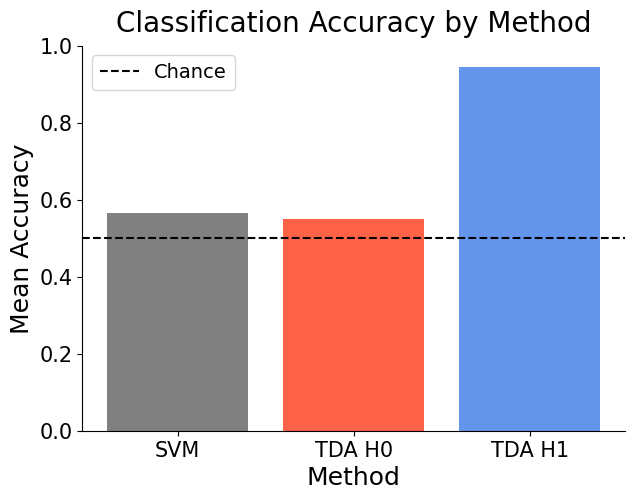

In [56]:
# barchart plot of df_results
import matplotlib.pyplot as plt
import pandas as pd
df_results = pd.read_csv("results_summary_degree_1_homology.csv")

# ---- font controls ----
legend_font_size = 14
font_size = 30
axes_titlesize = 20
axes_labelsize = 18
xtick_labelsize = 15
ytick_labelsize = 15
figure_titlesize = 20


plt.rcParams.update({
    "font.size": font_size,
    "axes.titlesize": axes_titlesize,
    "axes.labelsize": axes_labelsize,
    "xtick.labelsize": xtick_labelsize,
    "ytick.labelsize": ytick_labelsize,
    "legend.fontsize": legend_font_size,
    "figure.titlesize": figure_titlesize,
})

plt.figure(figsize=(7, 5))
plt.bar(df_results["Method"], df_results["Mean Accuracy"], color=['grey', 'tomato', 'cornflowerblue'])
plt.ylim(0, 1)
plt.title("Classification Accuracy by Method")
plt.ylabel("Mean Accuracy")
plt.xlabel("Method")
plt.axhline(y=1/2, color="black", linestyle="--", label="Chance")
plt.legend()
plt.savefig("classification_accuracy_comparison_degree-1-homology.pdf",bbox_inches='tight') 
# Get the current axes (gca)
ax = plt.gca()

# Hide the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

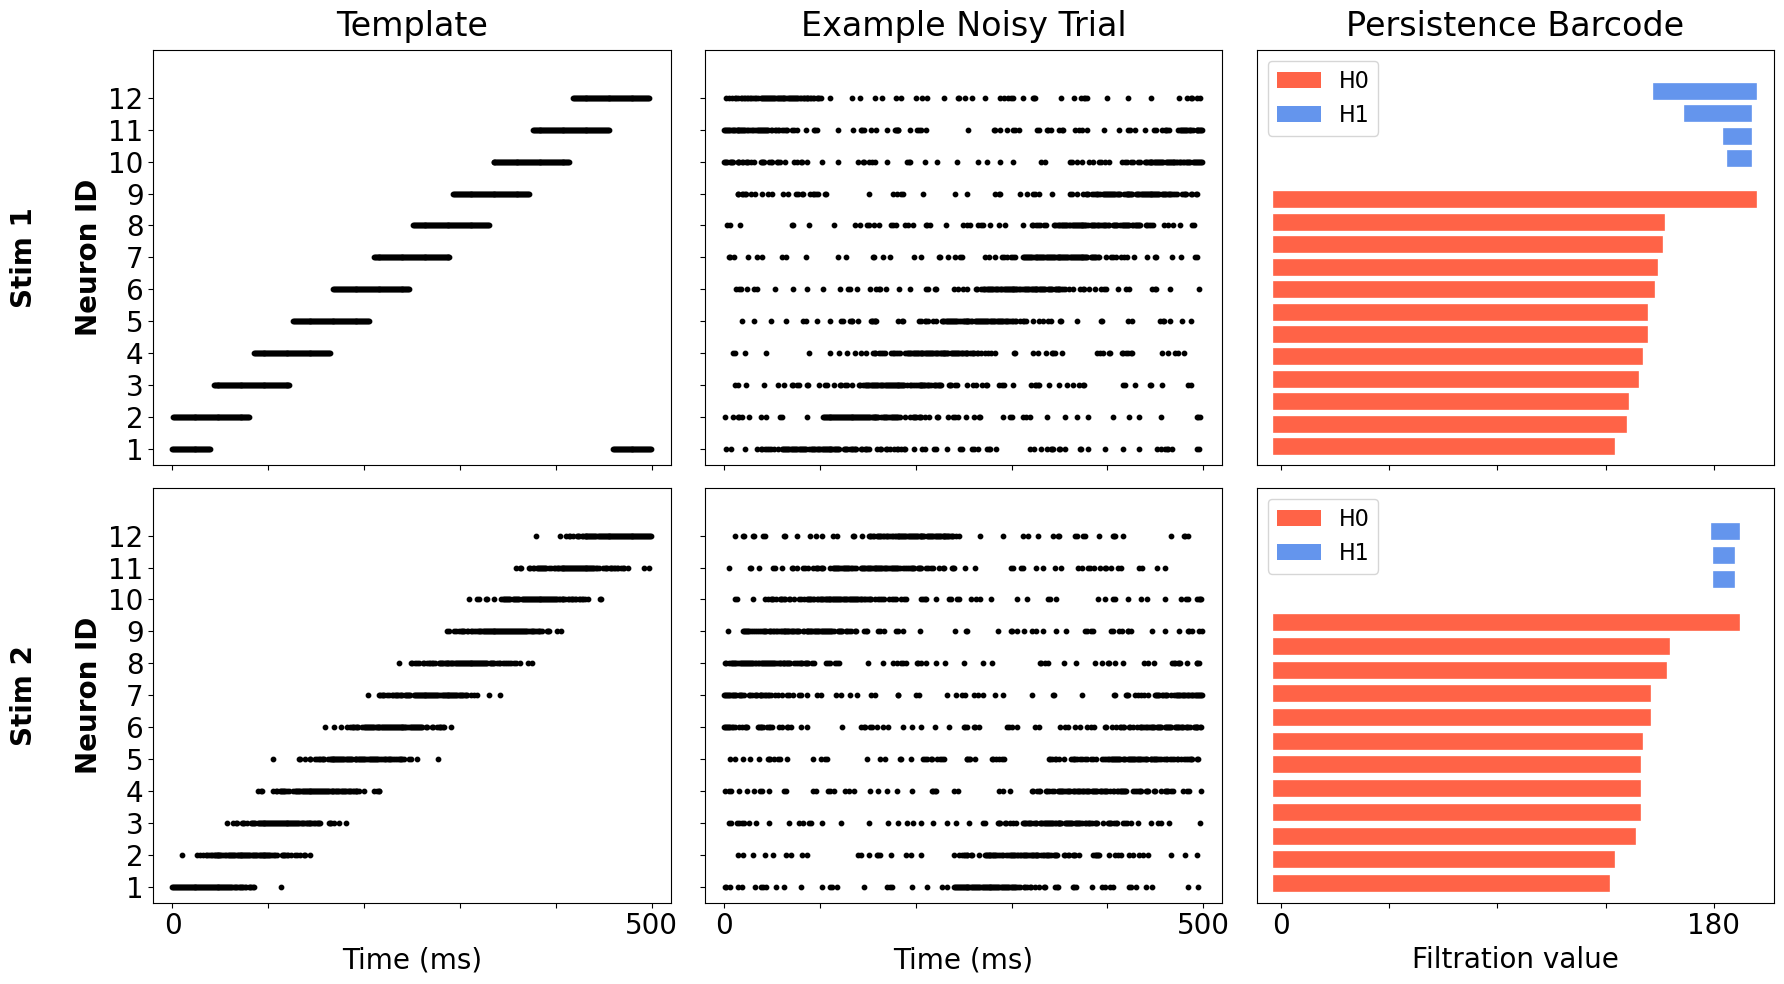

In [52]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    # --- Global Font Properties ---
    'font.family': 'sans-serif',    # Base font family (e.g., 'sans-serif', 'serif', 'monospace')
    'font.size': 12,                # Global default font size (affects everything not explicitly set below)
    
    # --- Figure & Subplot Titles ---
    'figure.titlesize': 22,         # Size of the overall figure title (plt.suptitle)
    'figure.titleweight': 'bold',   # Font weight of the overall figure title
    'axes.titlesize': 24,           # Size of individual subplot titles (ax.set_title)
    'axes.titleweight': 'normal',   # Font weight of subplot titles
    
    # --- Axis Labels (X and Y titles) ---
    'axes.labelsize': 20,           # Size of x and y axis labels (ax.set_xlabel, ax.set_ylabel)
    'axes.labelweight': 'normal',     # Font weight of axis labels
    
    # --- Tick Labels (The numbers/text on the axes) ---
    'xtick.labelsize': 20,          # Font size of x-axis tick numbers
    'ytick.labelsize': 20,          # Font size of y-axis tick numbers
    
    # --- Legend ---
    'legend.fontsize': 16,          # Font size of the text inside the legend
    'legend.title_fontsize': 16,    # Font size of the legend's title

    # --- pad---
    'axes.titlepad': 10
})

from ripser import ripser
import pickle


# -------------------------------------------------------------------------
# Main Plotting Script
# -------------------------------------------------------------------------

# upload templates and example trials from pickle files
with open("stim1_template.pkl", "rb") as f:
        stim1_template = pickle.load(f)
with open("stim2_template.pkl", "rb") as f:
        stim2_template = pickle.load(f)

with open("stim1_trials_example.pkl", "rb") as f:
        trial1 = pickle.load(f)
with open("stim2_trials_example.pkl", "rb") as f:
        trial2 = pickle.load(f)

dm1 = VP_trivial(trial1)
dgms1 = ripser(dm1, distance_matrix=True, maxdim=1)['dgms']

dm2 = VP_trivial(trial2)
dgms2 = ripser(dm2, distance_matrix=True, maxdim=1)['dgms']


fig, axes = plt.subplots(nrows=2, ncols=3, sharex=False, sharey=False, figsize=(18, 10))

# ---- font controls ----



plt.rcParams.update({
 
})
# --- Row 1: Stim 1 ---
# Plot 1: Clean Template
ax = axes[0,0]
plot_raster(stim1_template, title="Template", axes=ax)
ax.set_xlim(-20, 520)
# Plot 2: Noisy Trial
ax = axes[0, 1]
plot_raster(trial1, title="Example Noisy Trial", axes=ax)
ax.set_xlim(-20, 520)
# Plot 3: Trial Barcode
barcode_width = 12
ax = axes[0, 2]
plot_barcode(dgms1[0], dgms1[1], ax=ax,linewidth = barcode_width)
ax.set_title("Persistence Barcode")
# APPLY TICKS AND LIMITS AFTER PLOTTING
ax.set_xlim(-10, 205) # Force a shared fixed limit so they align vertically
ax.set_xticks([0, 45, 90, 135, 180])
ax.set_xticklabels(['', '', '', '', ''])

# --- Row 2: Stim 2 ---
# Plot 4: Optimized Template
ax = axes[1, 0]
ax.set_xticks([0, 100, 200, 300, 400, 500])
ax.set_xticklabels(['0', '', '', '', '', '500'])
plot_raster(stim2_template, title="", axes=ax)
ax.set_xlim(-20, 520)

# Plot 5: Noisy Trial
# Leave title blank for minimality since the top row already explains the column
ax = axes[1, 1]
ax.set_xticks([0, 100, 200, 300, 400, 500])
ax.set_xticklabels(['0', '', '', '', '', '500'])
plot_raster(trial2, title="", axes=ax)
ax.set_xlim(-20, 520)

# Plot 6: Trial Barcode
ax = axes[1, 2]
ax.set_xticks([0, 45, 90, 135, 180])
ax.set_xticklabels(['0', '', '', '', '180'])
plot_barcode(dgms2[0], dgms2[1], ax=ax, linewidth=barcode_width)
ax.set_title("") 
# APPLY TICKS AND LIMITS AFTER PLOTTING
ax.set_xlim(-10, 205) # Force the exact same limit as Row 1
ax.set_xticks([0, 45, 90, 135, 180])
ax.set_xticklabels(['0', '', '', '', '180'])


# --- Universal Axes Formatting & Clean Up ---

# Share Y-Axes & clever row labels
axes[0, 0].set_ylabel("Stim 1\n\nNeuron ID", fontweight='bold')
axes[1, 0].set_ylabel("Stim 2\n\nNeuron ID", fontweight='bold')

for i in range(2):
    # Remove y-axis labels and y-ticks for the middle raster column to share visually with col 0
    axes[i, 1].set_ylabel("")
    plt.setp(axes[i, 1].get_yticklabels(), visible=False)
    
    # Barcodes don't need y-labels
    axes[i, 2].set_ylabel("")

# Share X-Axes 
for j in range(3):
    # Hide x-tick numbers for top row (leaves the tick marks)
    plt.setp(axes[0, j].get_xticklabels(), visible=False)
    # Remove any default x-labels generated by plot_raster on the top row
    axes[0, j].set_xlabel("")

# Apply single shared X-Labels only to the bottom row
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 1].set_xlabel("Time (ms)")
axes[1, 2].set_xlabel("Filtration value")


plt.tight_layout()
plt.savefig('h1-example-plots.pdf', bbox_inches='tight')
plt.show()